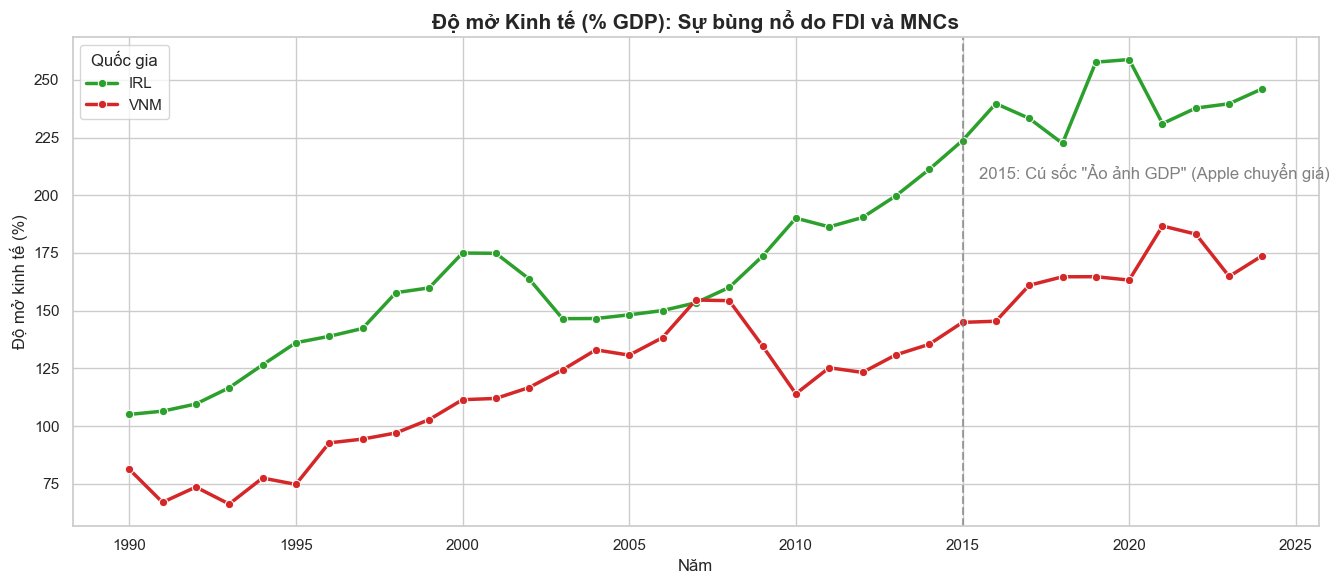

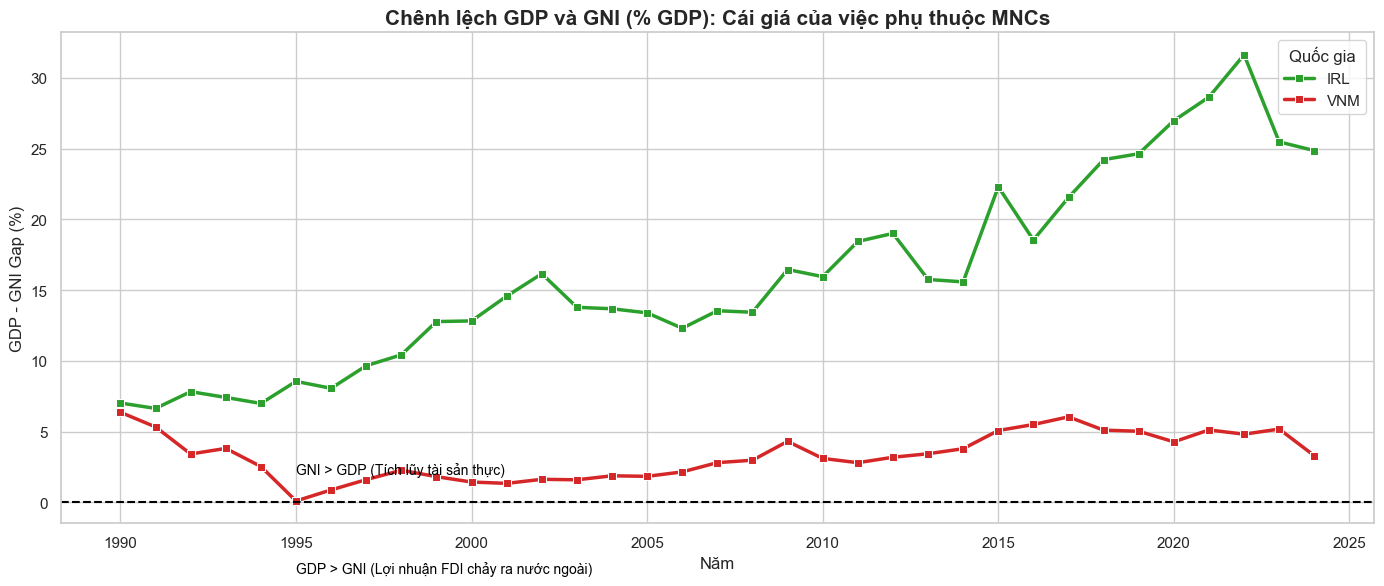

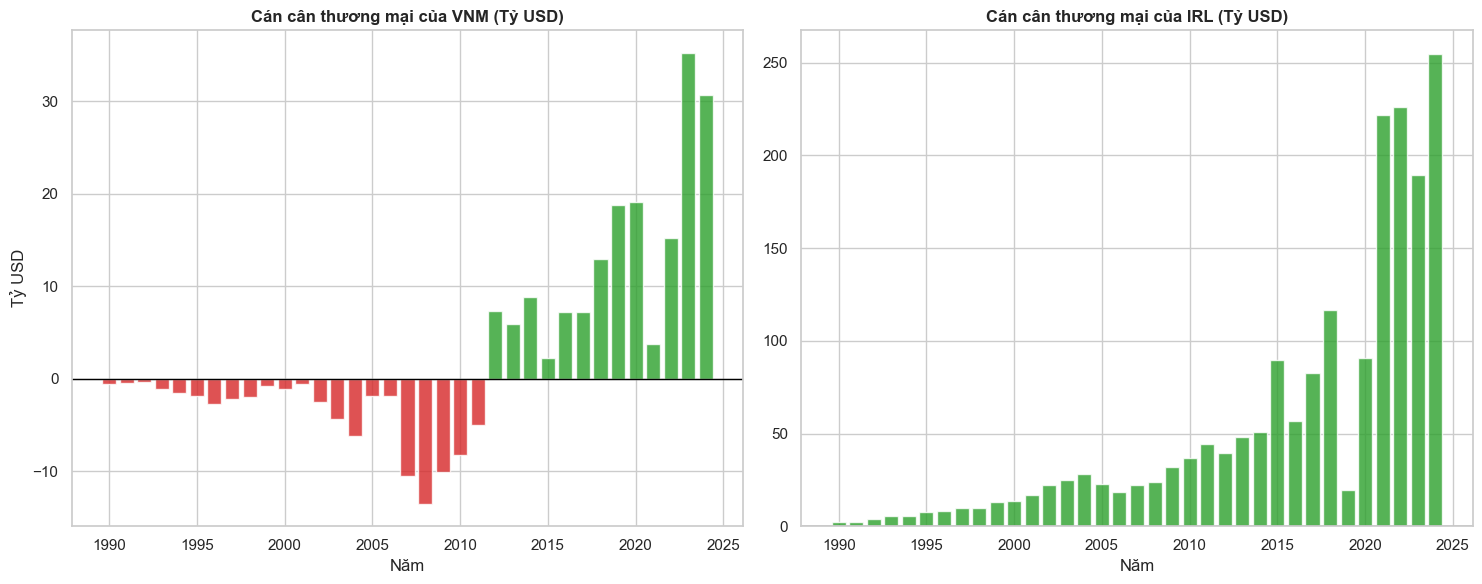

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style
sns.set_theme(style="whitegrid")

# Giả sử bạn đã load data:
df = pd.read_csv('cleaned_data/information/panel_macro_cleaned.csv')

# Lọc dữ liệu cho Việt Nam và Ireland
df_compare_irl = df[df['Country'].isin(['VNM', 'IRL'])].copy()

# ==========================================
# BIỂU ĐỒ 1: SỰ BÙNG NỔ ẢO ẢNH CỦA ĐỘ MỞ KINH TẾ
# ==========================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_compare_irl, x='Year', y='Economic_Openness_Pct', hue='Country', 
             linewidth=2.5, marker='o', palette={'VNM': '#d62728', 'IRL': '#2ca02c'})

# Đánh dấu sự kiện Leprechaun economics của Ireland
plt.axvline(x=2015, color='gray', linestyle='--', alpha=0.7)
plt.text(2015.5, df_compare_irl['Economic_Openness_Pct'].max()*0.8, '2015: Cú sốc "Ảo ảnh GDP" (Apple chuyển giá)', color='gray')

plt.title('Độ mở Kinh tế (% GDP): Sự bùng nổ do FDI và MNCs', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Độ mở kinh tế (%)', fontsize=12)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 2: BẢN CHẤT DÒNG TIỀN (GDP - GNI GAP) 
# Chìa khóa mổ xẻ chất lượng tăng trưởng
# ==========================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_compare_irl, x='Year', y='GDP_GNI_Gap_Pct', hue='Country', 
             linewidth=2.5, marker='s', palette={'VNM': '#d62728', 'IRL': '#2ca02c'})

plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.text(1995, 2, 'GNI > GDP (Tích lũy tài sản thực)', color='black', fontsize=10)
plt.text(1995, -5, 'GDP > GNI (Lợi nhuận FDI chảy ra nước ngoài)', color='black', fontsize=10)

plt.title('Chênh lệch GDP và GNI (% GDP): Cái giá của việc phụ thuộc MNCs', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('GDP - GNI Gap (%)', fontsize=12)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 3: SO SÁNH QUY MÔ XUẤT SIÊU DO FDI
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

for i, country in enumerate(['VNM', 'IRL']):
    country_data = df_compare_irl[df_compare_irl['Country'] == country]
    colors = ['#2ca02c' if val >= 0 else '#d62728' for val in country_data['Trade_Balance_USD']]
    
    axes[i].bar(country_data['Year'], country_data['Trade_Balance_USD'] / 1e9, color=colors, alpha=0.8)
    axes[i].set_title(f'Cán cân thương mại của {country} (Tỷ USD)', fontweight='bold')
    axes[i].axhline(0, color='black', linewidth=1)
    axes[i].set_xlabel('Năm')

axes[0].set_ylabel('Tỷ USD')
plt.tight_layout()
plt.show()

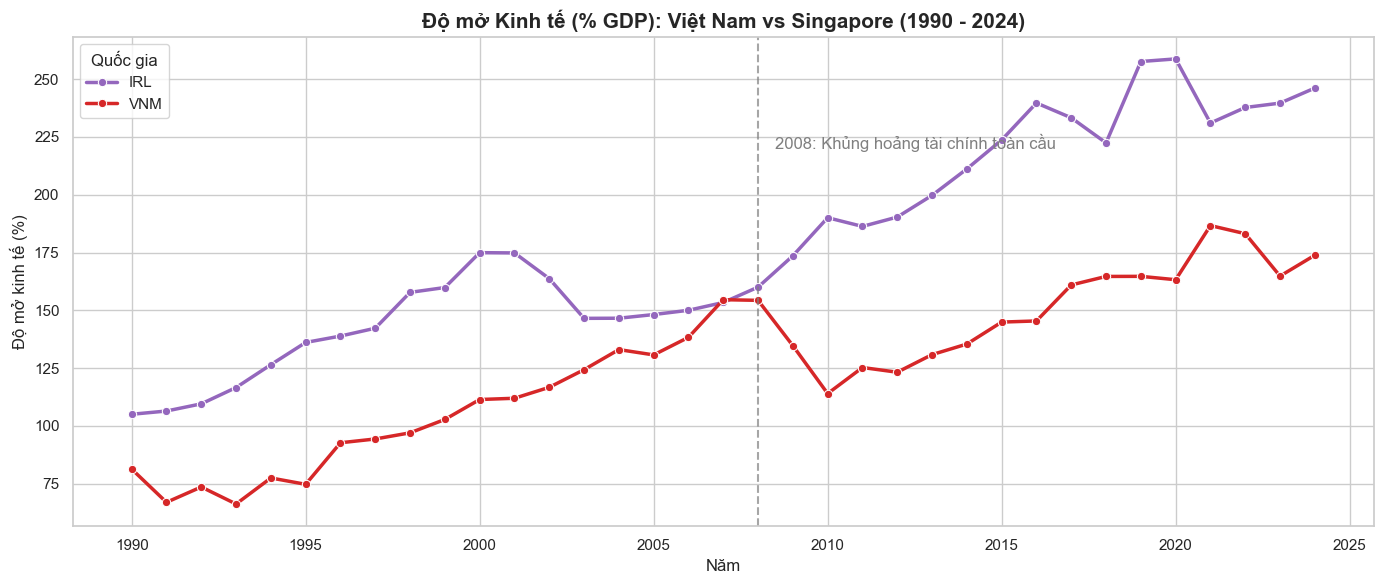

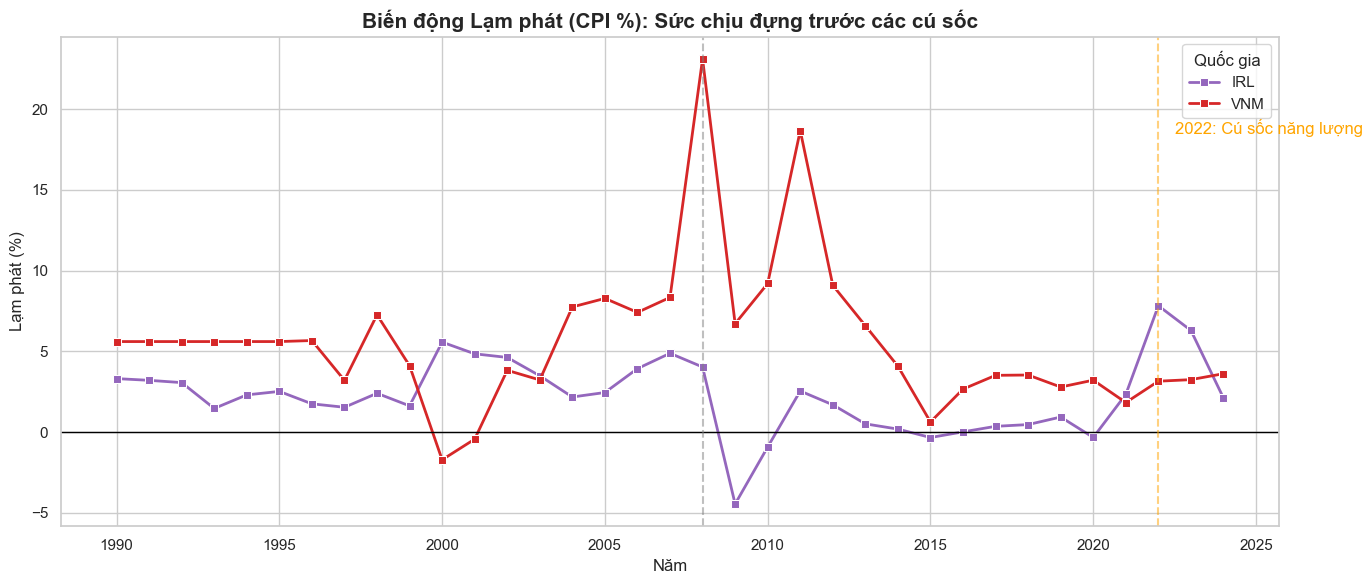

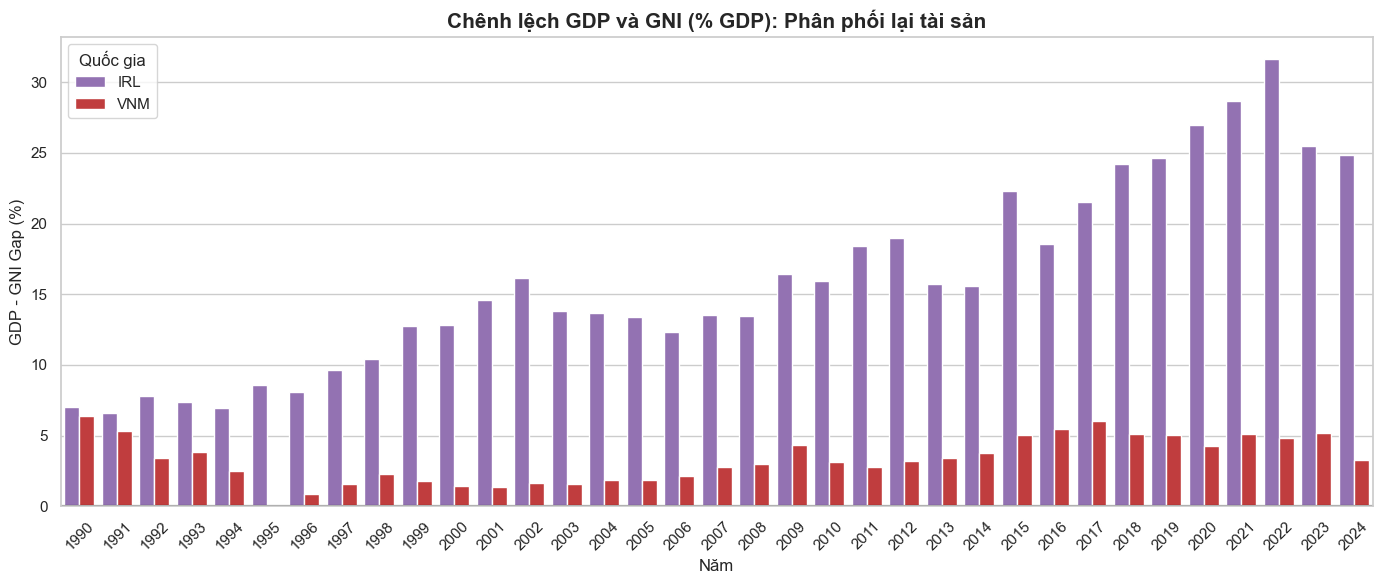

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style
sns.set_theme(style="whitegrid")

# Giả sử bạn đã load data từ trước:
df = pd.read_csv('cleaned_data/information/panel_macro_cleaned.csv')

# Lọc dữ liệu cho Việt Nam và Singapore
df_compare_IRL = df[df['Country'].isin(['VNM', 'IRL'])].copy()

# ==========================================
# BIỂU ĐỒ 1: QUỸ ĐẠO ĐỘ MỞ KINH TẾ (SỰ ĐIỀU CHỈNH CỦA IRL)
# ==========================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_compare_IRL, x='Year', y='Economic_Openness_Pct', hue='Country', 
             linewidth=2.5, marker='o', palette={'VNM': '#d62728', 'IRL': '#9467bd'})

# Thêm mốc khủng hoảng toàn cầu
plt.axvline(x=2008, color='gray', linestyle='--', alpha=0.7)
plt.text(2008.5, df_compare_IRL['Economic_Openness_Pct'].max()*0.85, '2008: Khủng hoảng tài chính toàn cầu', color='gray')

plt.title('Độ mở Kinh tế (% GDP): Việt Nam vs Singapore (1990 - 2024)', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Độ mở kinh tế (%)', fontsize=12)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 2: BỘ ĐẶM VĨ MÔ & KHẢ NĂNG CHỐNG SỐC (LẠM PHÁT)
# ==========================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_compare_IRL, x='Year', y='Inflation_CPI_Pct', hue='Country', 
             linewidth=2, marker='s', palette={'VNM': '#d62728', 'IRL': '#9467bd'})

plt.axhline(0, color='black', linewidth=1)
plt.axvline(x=2008, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5)
plt.text(2022.5, df_compare_IRL['Inflation_CPI_Pct'].max()*0.8, '2022: Cú sốc năng lượng', color='orange')

plt.title('Biến động Lạm phát (CPI %): Sức chịu đựng trước các cú sốc', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Lạm phát (%)', fontsize=12)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 3: BẢN CHẤT CỦA SỰ SIÊU MỞ (GDP VS GNI GAP)
# ==========================================
plt.figure(figsize=(14, 6))
sns.barplot(data=df_compare_IRL, x='Year', y='GDP_GNI_Gap_Pct', hue='Country', palette={'VNM': '#d62728', 'IRL': '#9467bd'})

plt.axhline(0, color='black', linewidth=1.5)
plt.title('Chênh lệch GDP và GNI (% GDP): Phân phối lại tài sản', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('GDP - GNI Gap (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()